# Deduplication Reduction Factor Landscape

This notebook visualizes the relationship between event log properties (number of unique activities, average trace length) and the deduplication reduction factor across all XES datasets.

**Color coding**: Green (low reduction) → Red (high reduction)
- Green: Few duplicates found (0% reduction)
- Red: Many duplicates found (100% reduction)

In [1]:
import sys
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import torch

sys.path.append("../../..")

from dataloaders.xes_log import XESEventLogDataset
from dataloaders.net import ProcessModelDataset, VariantRandomDistributionSampler
from dataloaders.unique_net import UniqueProcessModelDataset
from deduplication.deduplicator import DeduplicationConfig
from pm4py.discovery import discover_petri_net_inductive

## Dataset Configuration

Define all XES datasets to process. This is the same mapping used in `evaluate_deduplication.py`.

In [2]:
# Dataset mapping (only .xes files)
DATASETS = {
    # fast datasets
    '3537c19d-6c64-4b1d-815d-915ab0e479da': ['BPI_Challenge_2013_open_problems.xes'],
    'db35afac-2133-40f3-a565-2dc77a9329a3': ['PermitLog.xes'],
    '500573e6-accc-4b0c-9576-aa5468b10cee': ['BPI_Challenge_2013_incidents.xes'],
    'c2c3b154-ab26-4b31-a0e8-8f2350ddac11': ['BPI_Challenge_2013_closed_problems.xes'],
    '91fd1fa8-4df4-4b1a-9a3f-0116c412378f': ['InternationalDeclarations.xes'],
    'a6f651a7-5ce0-4bc6-8be1-a7747effa1cc': ['RequestForPayment.xes'],
    'fb84cf2d-166f-4de2-87be-62ee317077e5': ['PrepaidTravelCost.xes'],
    '6a0a26d2-82d0-4018-b1cd-89afb0e8627f': ['DomesticDeclarations.xes'],
    
    # not tested datasets
    '5f3067df-f10b-45da-b98b-86ae4c7a310b': ['BPI%20Challenge%202017.xes'],
    '6af6d5f0-f44c-49be-aac8-8eaa5fe4f6fd': ['Hospital%20Billing%20-%20Event%20Log.xes'],
    '12683249': ['Road_Traffic_Fine_Management_Process.xes'],
    '33632f3c-5c48-40cf-8d8f-2db57f5a6ce7': ['Sepsis%20Cases%20-%20Event%20Log.xes'],
    'b32c6fe5-f212-4286-9774-58dd53511cf8': ['BPIC15_5.xes'],
    'd9769f3d-0ab0-4fb8-803b-0d1120ffcf54': ['Hospital_log.xes'],
    'a0addfda-2044-4541-a450-fdcc9fe16d17': ['BPIC15_1.xes'],
    'd06aff4b-79f0-45e6-8ec8-e19730c248f1': ['BPI_Challenge_2019.xes'],
    '3926db30-f712-4394-aebc-75976070e91f': ['BPI_Challenge_2012.xes'],
    
    # slow datasets
    '63a8435a-077d-4ece-97cd-2c76d394d99c': ['BPIC15_2.xes'],
    '679b11cf-47cd-459e-a6de-9ca614e25985': ['BPIC15_4.xes'],
    'ed445cdd-27d5-4d77-a1f7-59fe7360cfbe': ['BPIC15_3.xes'],
    # '3301445f-95e8-4ff0-98a4-901f1f204972': ['BPI%20Challenge%202018.xes'],
}

DATA_DIR = Path("../../../data")

print(f"Total datasets to process: {sum(len(files) for files in DATASETS.values())}")

Total datasets to process: 20


## Data Collection

For each dataset:
1. Load event log and compute properties (n_unique_activities, avg_trace_len)
2. Create ProcessModelDataset with 100 models
3. Apply deduplication with UniqueProcessModelDataset
4. Extract reduction factor from deduplication report

**Note**: This cell will take some time on first execution. Subsequent runs will be much faster due to caching.

In [3]:
def process_dataset(dataset_uuid, filename):
    """
    Process a single dataset and return its properties and deduplication results.
    
    Returns:
        dict with keys: name, n_unique_activities, avg_trace_len, reduction_factor
        or None if processing failed
    """
    dataset_path = DATA_DIR / dataset_uuid / filename
    
    if not dataset_path.exists():
        print(f"WARNING: Dataset not found at {dataset_path}")
        return None
    
    try:
        # Load event log
        log_dataset = XESEventLogDataset(str(dataset_path), attribute="concept:name")
        log = log_dataset.log
        
        # Compute event log properties
        unique_activities = set()
        trace_lengths = []
        
        for trace in log:
            trace_lengths.append(len(trace))
            for event in trace:
                unique_activities.add(event["concept:name"])
        
        n_unique_activities = len(unique_activities)
        avg_trace_len = np.mean(trace_lengths)
        
        # Create ProcessModelDataset
        pm_dataset = ProcessModelDataset(
            log_dataset=log_dataset,
            discovery_methods={"inductive": discover_petri_net_inductive},
            param_grid={
                "noise_threshold": [0.0, 0.1, 0.2, 0.3, 0.4],
                "disable_fallthroughs": [True],
            },
            sampler_specs={
                "variant_random": VariantRandomDistributionSampler(
                    n_subsets=1000,
                    max_len_subset=100,
                    min_len_subset=10,
                    len_distribution=torch.distributions.Exponential(
                        torch.tensor([1.0 / 100.0])
                    ),
                    freq_distribution=torch.distributions.Normal(10.0, 5.0),
                    reconstruct_frequency=True,
                )
            },
            cached=True,
            max_models=100,
        )
        
        # Apply deduplication
        dedup_config = DeduplicationConfig()
        unique_dataset = UniqueProcessModelDataset(
            base_dataset=pm_dataset,
            dedup_config=dedup_config,
            force_recompute=False,  # Use cache if available
        )
        
        # Extract reduction factor
        reduction_factor = unique_dataset.dedup_report.get('reduction_percent', 0.0)
        
        return {
            'name': filename.replace('.xes', ''),
            'n_unique_activities': n_unique_activities,
            'avg_trace_len': avg_trace_len,
            'reduction_factor': reduction_factor,
            'num_total': unique_dataset.dedup_report.get('num_total', 0),
            'num_unique': unique_dataset.dedup_report.get('num_unique', 0),
        }
        
    except Exception as e:
        print(f"ERROR processing {filename}: {str(e)}")
        return None


# Process all datasets
results = []
failed_datasets = []

total_datasets = sum(len(files) for files in DATASETS.values())
pbar = tqdm(total=total_datasets, desc="Processing datasets")

for dataset_uuid, files in DATASETS.items():
    for filename in files:
        pbar.set_description(f"Processing {filename}")
        result = process_dataset(dataset_uuid, filename)
        
        if result is not None:
            results.append(result)
        else:
            failed_datasets.append(filename)
        
        pbar.update(1)

pbar.close()

print(f"\nSuccessfully processed: {len(results)} datasets")
print(f"Failed: {len(failed_datasets)} datasets")
if failed_datasets:
    print(f"Failed datasets: {failed_datasets}")

Processing BPI_Challenge_2013_open_problems.xes:   0%|          | 0/20 [00:00<?, ?it/s]/Users/michael/anaconda3/envs/praktikum_process_mining/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 819/819 [00:00<00:00, 6516.80it/s]
INFO:root:Total discovery configurations generated: 100
INFO:root:Populating process model cache...
Caching discovered models: 0it [00:00, ?it/s]
INFO:root:Cache population done (760 models).
INFO:root:Loaded 4 unique indices from cache (../../../data/3537c19d-6c64-4b1d-815d-915ab0e479da/.cache_unique_models/unique_dedup_9b36b03366a0e7d5.pkl)
parsing log, completed traces :: 100%|██████████| 7065/7065 [00:01<00:00, 3753.13it/s]         
INFO:root:Total discovery configurations generated: 100
INFO:root:Populating process model cache..


Successfully processed: 20 datasets
Failed: 0 datasets


## Results Summary

In [21]:
# Display results as a table
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values('reduction_factor', ascending=False)
df

,name,n_unique_activities,avg_trace_len,reduction_factor,num_total,num_unique
3,BPI_Challenge_2013_closed_problems,4,4.478816,98.0,100,2
0,BPI_Challenge_2013_open_problems,3,2.870574,96.0,100,4
16,BPI_Challenge_2012,24,20.035149,96.0,100,4
2,BPI_Challenge_2013_incidents,4,8.675271,95.0,100,5
10,Road_Traffic_Fine_Management_Process,11,3.733923,93.0,100,7
8,BPI%20Challenge%202017,26,38.156305,92.0,100,8
7,DomesticDeclarations,17,5.374952,79.0,100,21
9,Hospital%20Billing%20-%20Event%20Log,18,4.513590,78.0,100,22
11,Sepsis%20Cases%20-%20Event%20Log,16,14.489524,77.0,100,23
5,RequestForPayment,19,5.343596,74.0,100,26


## Visualization

Scatter plot showing the relationship between event log properties and deduplication reduction factor.

**Interpretation**:
- **X-axis**: Number of unique activities in the event log
- **Y-axis**: Average trace length
- **Color**: Reduction factor (Green = low reduction/few duplicates, Red = high reduction/many duplicates)

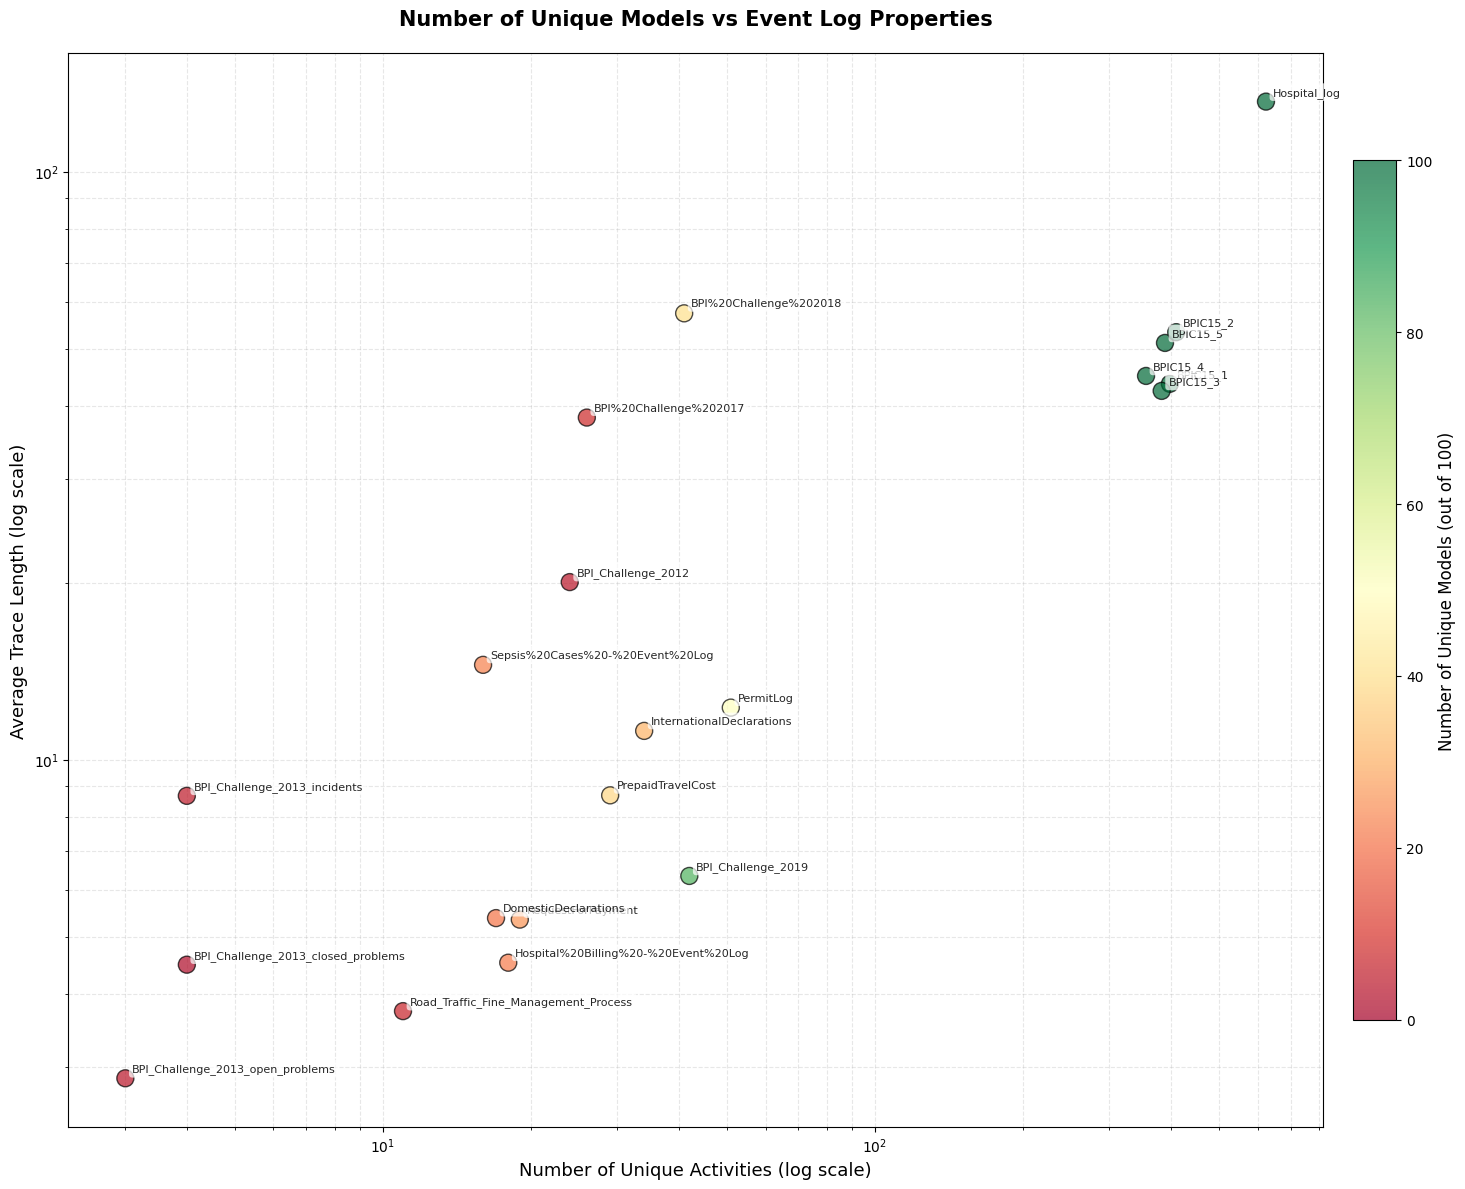


Number of Unique Models Statistics:
  Mean: 45.9
  Median: 31.0
  Min: 2.0
  Max: 100.0
  Std: 38.7

Reduction Factor Statistics:
  Mean: 54.1%
  Median: 69.0%
  Min: 0.0%
  Max: 98.0%
  Std: 38.7%


In [22]:
# Extract data for plotting
names = [r['name'] for r in results]
n_activities = np.array([r['n_unique_activities'] for r in results])
avg_trace_lengths = np.array([r['avg_trace_len'] for r in results])
reduction_factors = np.array([r['reduction_factor'] for r in results])

# Calculate number of unique models (inverse of reduction factor)
num_unique = np.array([r['num_unique'] for r in results])

# Create scatter plot
fig, ax = plt.subplots(figsize=(16, 12))

scatter = ax.scatter(
    n_activities,
    avg_trace_lengths,
    c=num_unique,
    cmap='RdYlGn',  # Red (low) → Yellow → Green (high)
    vmin=0,
    vmax=100,
    s=150,  # Point size
    alpha=0.7,
    edgecolors='black',
    linewidths=1.0,
    zorder=2
)

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Add annotations for dataset names with smart positioning
# Use adjustText library for automatic label positioning to avoid overlaps
try:
    from adjustText import adjust_text
    
    texts = []
    for i, name in enumerate(names):
        text = ax.annotate(
            name,
            (n_activities[i], avg_trace_lengths[i]),
            fontsize=8,
            alpha=0.85,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
            zorder=3
        )
        texts.append(text)
    
    # Adjust text positions to avoid overlaps
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
        expand_points=(1.5, 1.5),
        force_text=(0.5, 0.5),
        force_points=(0.2, 0.2),
        ax=ax
    )
    
except ImportError:
    # Fallback: manual positioning with offset
    for i, name in enumerate(names):
        # Use consistent offset in log space
        offset_x = 5
        offset_y = 5
        
        ax.annotate(
            name,
            (n_activities[i], avg_trace_lengths[i]),
            fontsize=8,
            alpha=0.85,
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
            zorder=3
        )

# Axis labels and title
ax.set_xlabel("Number of Unique Activities (log scale)", fontsize=13)
ax.set_ylabel("Average Trace Length (log scale)", fontsize=13)
ax.set_title("Number of Unique Models vs Event Log Properties", fontsize=15, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', which='both', zorder=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Number of Unique Models (out of 100)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nNumber of Unique Models Statistics:")
print(f"  Mean: {num_unique.mean():.1f}")
print(f"  Median: {np.median(num_unique):.1f}")
print(f"  Min: {num_unique.min():.1f}")
print(f"  Max: {num_unique.max():.1f}")
print(f"  Std: {num_unique.std():.1f}")

print(f"\nReduction Factor Statistics:")
print(f"  Mean: {reduction_factors.mean():.1f}%")
print(f"  Median: {np.median(reduction_factors):.1f}%")
print(f"  Min: {reduction_factors.min():.1f}%")
print(f"  Max: {reduction_factors.max():.1f}%")
print(f"  Std: {reduction_factors.std():.1f}%")

## Save Results

Save the collected data as JSON for later use.

In [6]:
output_file = Path("deduplication_landscape_results.json")

with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_file.absolute()}")

Results saved to: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/experiments/dataset/survey/deduplication_landscape_results.json
